# Retrieving dust properties

In this page, we aim to retrieve dust proparties such as surface densities as a function of radius by directly fitting the FRAP model to the interferometric visibilities. We assume that the data have already been averaged and deprojected (see [Data preparation](tutorial_0.ipynb)).

## 1. Import modules and data

First, we import several modules in addition to FRAP.

In [1]:
import frap
import numpyro
import pickle
import dsharp_opac
import jax.numpy as jnp

We then set the number of the CPUs (or GPU devices if you have - note: we have not test any GPU calcuration yet) for parallel calcuration. I'm currently running this notebook on a Macbook Pro and it has 10 cores, so I set "10".

In [2]:
numpyro.set_host_device_count(10)

We have to prepare the one-dimentional visibility profiles in advance (see [Data preparation](tutorial_0.ipynb)). As an example, here we have observations of the HD169142 disk in two bands: ALMA band 3 and 6. Those files are on the [repository](https://github.com/tomyoshida/frap/tree/16121c01b8fd117b430e179b6c200dc77b1c0cde/example_data).

For a better management of the data, we set a list and corresponding dictonary.

In [4]:
bands = [ 'band3', 'band6' ]
data = {
    'band3' : 'HD169142_band3.pkl',
    'band6' : 'HD169142_band6.pkl'
}

Let's load the files to a dictionally.

In [5]:
obs = {}

for band in bands:
    with open(data[band], 'rb') as f:
        obs[band] = pickle.load(f)
        

The data structure depends on how did you make the pkl file. However, if you followed the turorial, you have keys something like this:

In [6]:
obs['band3'].keys(), obs['band3']['q'].keys()

(dict_keys(['q', 'V', 's', 'nu', 'Nch']), dict_keys([0, 1]))

'q', 'V', 's', 'nu', and 'Nch' are the uv distance, real part of the visibilities, standard deviation, frequency, and number of channels. Each channels are stored as a dictionary in each element.

We assume the dust opacity model. Here we adopt [the DSHARP default opacity](https://github.com/birnstiel/dsharp_opac). 

In [8]:
dust_opacity = jnp.load(dsharp_opac.get_datafile('default_opacities_smooth.npz'))

## 2. Set the disk model

Then we set the FRAP disk model which we'll fit to the data. First, we do some calcuration setting. We assume the inclination angle of 6.28 deg and the outer disk edge of 1.3 arcsec. We'll set a length scale of the gaussian process to be 0.04 arcsec later, therefore, we set the number of sampling point of the Gaussian process to be 130 so that the typical seperation becomes ~0.01 arcsec. Note that the radial grid is not perfectly evenly spaced. We also set the disk position angle. This is used only for projection of the primary beam onto the disk coordinate.

In [9]:
disk = frap.model( incl= 6.28,
                     pa = 6.3,
                     r_out = 1.3,
                     N_GP = 130,
                     flux_uncert = True )

In this tutorial, we have only two bands - band 3 and 6. This is not really sufficient to constrain many parameters. So, let's fix the temperature profile in advance. Such parameters can be added like this:

In [10]:
D = 114.9 # pc

disk.set_parameter('log10_T', 
                   free = False, 
                   profile = lambda r: jnp.log10(77.0*(r*D/10)**(-0.5)) )

We assume the temperature profile obtained by [Macías et al. (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/ab31a2/meta). The input `profile` can also support a jnp.ndarray.

We should also fix the power-law profile of the dust size distribution, q, to be the MRN distribution of 3.5.

In [11]:
disk.set_parameter('q', 
                   free = False, 
                   profile = lambda r: 3.5 )

We instead try to fit the gas surface densities and the maximum grain size in this tutorial. We adopt a lengthscale of 0.04 arcsec in this example, but you may change depending on your interest. The parameter "bounds" is a tuple of the lower and upper limit of the parameter. The lower bound of a_max is set to be 100 um. This might be important particularly for this example since there are two possible solutions and the gaussian process sometimes can't manage this situation. Note that we assume CGS units.

In [12]:
lengthscale = 0.03

disk.set_parameter('log10_Sigma_d', free = True,
                                    bounds = ( -6.0, 3.0 ), 
                                    lengthscale = lengthscale)

disk.set_parameter('log10_a_max', free = True, 
                                    bounds =  ( -2.0, 2.0 ),
                                    lengthscale = lengthscale)

We set the observational data for each band. The inputs q, V, s assume a dictionary of channel indices. Simutaneously, we can set the absolute flux scaling factors and its uncertainty.

In [13]:
f_s = { 'band3': 0.025, 'band6': 0.05 }
f_mean = { 'band3': 1.0, 'band6': 1.0 }
    
for band in bands:
    disk.set_visibility( band = band,
                            q = obs[band]['q'],
                            V = obs[band]['V'],
                            s = obs[band]['s'],
                            nu = obs[band]['nu'],
                            Nch = obs[band]['Nch'],
                            f_s = f_s[band],
                            f_mean = f_mean[band]
                       )

The last thing that FRAP has to know is the opacity. As it depends on the frequency of the data, we have to run this after set_observations. By default, this function performs smoothing of the opacities along the dust size direction with a width of $\log_{\rm 10}(a) = 0.05$. This is to avoid the wiggling due to Mie interference that could make the Hamiltonian "bumpy" and affects sampling.

In [14]:
disk.set_opacity( opac_dict = dust_opacity )

## 3. Run MCMC sampling

Now the model is all set! We launch the inference function.

In [15]:
inference = frap.inference(disk)

Before running MCMC sampling, we should check the priors.

In [16]:
prior = inference.prior(num_samples=10)
plotter = frap.plot( prior )

saved keys:  dict_keys(['prior_f', 'prior_g'])


`frap.plot()` shows what samples you can see. If you are interested in the prior of the function of the physical quantities, chose 'prior_f'. On the other hand, 'prior_g' is the latent function of the gaussian process.

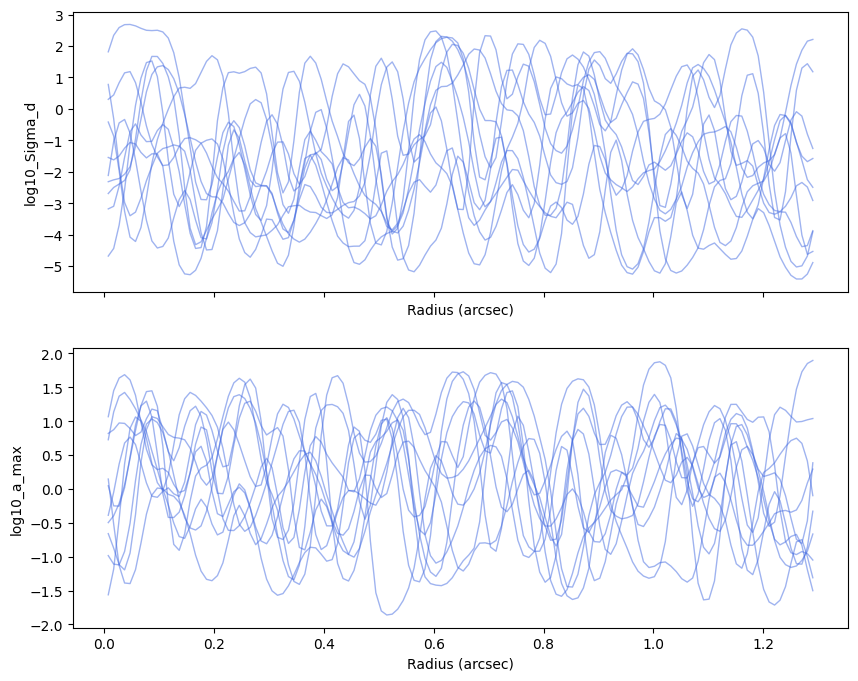

In [17]:
plotter.sample_paths( 'prior_f', nskip = 1 )

If you are satisfied with this, let's start the MCMC sampling! "num_chains" is set to be the same as the number of your CPU cores. You may want to increase the number of the chains more than the number of CPUs. In those case, you could just run the sampling again in series and combine the posterior sample later.

The function runs the warm-up (a.k.a burn-in) sampling and main sampling seperately.

In [18]:
num_warmup = 5000
num_samples = 5000
num_chains = 10

posterior = inference.MCMC( num_warmup = num_warmup, 
                            num_samples = num_samples,
                            num_chains = num_chains )

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]


                            mean       std    median      5.0%     95.0%     n_eff     r_hat
       g_f_scale_band3      9.65      0.28      9.66      9.18     10.10  19718.00      1.00
       g_f_scale_band6      6.27      0.11      6.27      6.08      6.46  17720.24      1.00
  g_log10_Sigma_d_z[0]      0.58      0.02      0.58      0.54      0.62  29920.14      1.00
  g_log10_Sigma_d_z[1]     -0.95      0.28     -0.92     -1.38     -0.51  19314.26      1.00
  g_log10_Sigma_d_z[2]     -0.90      0.79     -0.87     -2.19      0.39  48833.86      1.00
  g_log10_Sigma_d_z[3]     -0.72      0.89     -0.72     -2.22      0.71  54574.03      1.00
  g_log10_Sigma_d_z[4]     -0.61      0.92     -0.61     -2.13      0.90  57114.83      1.00
  g_log10_Sigma_d_z[5]     -0.67      0.92     -0.67     -2.23      0.82  56303.99      1.00
  g_log10_Sigma_d_z[6]     -0.75      0.93     -0.74     -2.27      0.77  55654.78      1.00
  g_log10_Sigma_d_z[7]     -0.75      0.90     -0.74     -2.21      0

In my case (MacBook Pro, M5), it tooks ~15 minutes to run this. Note that the time needed for convergence significantly depends on the problem.

## 4. Inspect the results

Finally, we inspect the results. We can plot the posterior distribution as follows.

In [19]:
plotter = frap.plot( posterior )

saved keys:  dict_keys(['warmup_f', 'posterior_f', 'warmup_g', 'posterior_g'])


We want to see the posterior of the physical quantities, therefore,

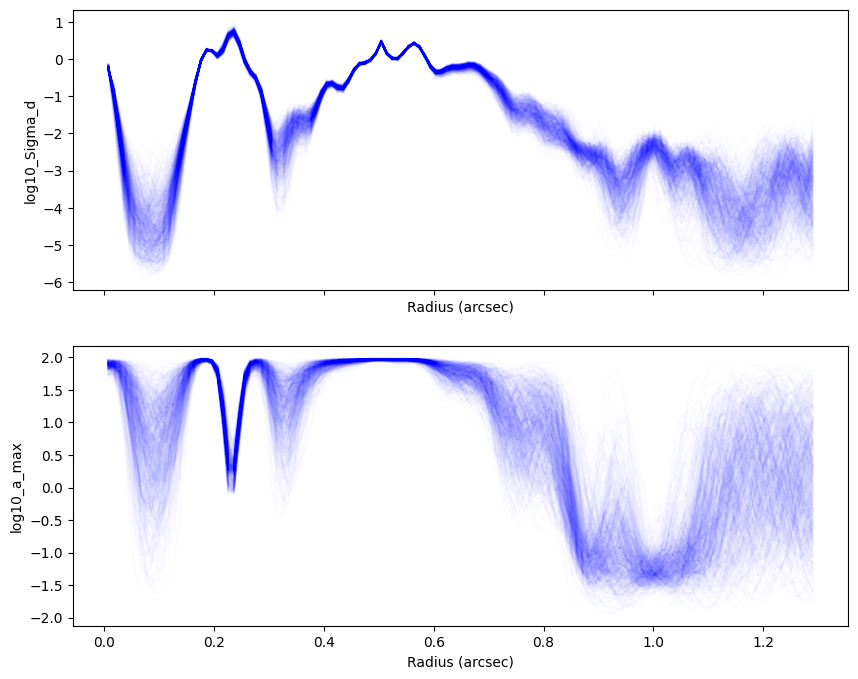

In [20]:
plotter.sample_paths( 'posterior_f', nskip = 100, plot_kwargs = { 'alpha' : 0.01, 'color' : 'b' } )

`posterior` has those results and you can save it.

In [21]:
with open('./mcmc_reuslts.pkl', 'wb') as f:
    pickle.dump( posterior, f )

You can access to an numpy array of the the samples by e.g., `posterior.sample['posterior_f']`. You may want to assess the samples directly, or make a plot as in the [next section](tutorial_2.ipynb)